# Hands-On 2 — Predict → Route → Allocate

> ▶️ **Open in Google Colab (one tap):** https://colab.research.google.com/github/thakkarkhyati/IIMK_Tutorials/blob/main/AI_Logistics_Railways_3hr/03b_HandsOn_Predict_Route_Allocate.ipynb  — then *Runtime → Run all*.
### Decision intelligence on the railway map

**IIM Kozhikode · MDP for IRMS/IAS Officers · Trainer: Khyati Thakkar (HERE Technologies)**

---
#### What you'll learn
Building directly on the Hands-on 1 network, you will:
1. **PREDICT** — train a small, readable model to predict **section transit time**, and read *which
   factors drive it*.
2. **ROUTE** — use those predictions as edge weights and find a rake's **best path** — exactly how a
   maps app routes you around traffic.
3. **DIGITAL TWIN** — block a section (or let **condition monitoring** flag a degraded one) and watch
   the route **re-plan itself**, priced in hours and ₹.
4. **ALLOCATE** — predict each order's value and use a transparent **scorecard** to assign rakes to
   demands — beating first-come-first-served, with every choice explainable.

> **The mental model:** *Decision = Prediction + a simple rule.* ML does the hard part (Engine 1);
> the routing/allocation rules (Engine 2) stay simple, transparent and auditable. **No optimization
> theory needed.**

> **Net-new content:** this does not repeat the anomaly-detection or delay-correlation notebooks —
> it's about *deciding* on the network. Runs fully offline; real-Kaggle swap-in noted inline.

---
> ▶️ **How to run:** Colab → `File → Upload notebook` → `Runtime → Run all`. It runs top-to-bottom;
> if a cell complains, re-run from Part 0 (`seed = 7`, so everyone sees the same numbers). Outputs are
> pre-saved, so a shy projector won't derail you.
>
> 🧠 *We're about to let a computer decide "the long way round is actually faster." If that offends
> your inner controller — good. That reflex is exactly what we're here to pressure-test.*


## 0. Setup

In [1]:
# Run once if a package is missing (Colab already has most of these):
# !pip install -q numpy pandas matplotlib networkx scikit-learn
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    """Import pkg; pip-install quietly if missing, then import. Keeps class moving."""
    try:
        return importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
        return importlib.import_module(pkg)

np = _ensure("numpy")
pd = _ensure("pandas")
import matplotlib.pyplot as plt
nx = _ensure("networkx")
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(7)

# House style — same palette as Session 3 and the slide deck.
THEME = {
    "navy":  "#122136", "teal": "#00A8A0", "tealD": "#007A74",
    "amber": "#E88A00", "grey": "#9AA5B1", "ink": "#1E2A38",
}
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.titlecolor"] = THEME["ink"]
print("Setup complete — palette matched to Session 3. 🎨")


Setup complete — palette matched to Session 3. 🎨


---
# Part 1 — Rebuild the Map (same corridor as Hands-on 1)

Same network, now with **per-section attributes** the model can learn from: length, typical traffic
(trains/day), and gradient (a steel-plant climb is slower).

> **Real-data swap-in:** build this graph from `kaggle.com/datasets/rohan26x/indian-express-train-dataset`
> (station-to-station routes) and attach real section attributes.

In [2]:
SCALE = 6.0
# Stylised Mumbai-Pune corridor (schematic, not to scale). Two approaches to Karjat
# (via Kalyan = shortest km but busy/hilly; via Panvel-Kalamboli = a bit longer but faster),
# then the Bhor Ghat (Karjat->Lonavala->Pune), with the inland Daund loop as the long detour.
_raw = {
    "JNPT": (0,0), "Kalyan": (16,6), "Panvel": (10,-4), "Kalamboli": (14,-10),
    "Karjat": (34,0), "Lonavala": (52,2), "Pune": (78,0),
    "Ahmadnagar": (56,28), "Daund": (74,16),
}
stations = {k: (x*SCALE, y*SCALE) for k, (x, y) in _raw.items()}

# (from, to, trains_per_day, gradient_pct)
sec_attr = [
    ("JNPT","Panvel",  18, 0.2),
    ("JNPT","Kalyan",  26, 0.3),        # shortest-km approach, but busy
    ("Kalyan","Karjat",30, 0.6),        # busy + hilly -> slower than it looks
    ("Panvel","Kalamboli",16, 0.3),     # longer approach...
    ("Kalamboli","Karjat",14, 0.3),     # ...but faster (quieter, flatter)
    ("Karjat","Lonavala",24, 1.0),      # THE BHOR GHAT: short climb, normally the chosen route
    ("Karjat","Ahmadnagar",12, 0.5),    # inland alternate (flatter, much longer)
    ("Ahmadnagar","Daund",12, 0.4),
    ("Lonavala","Daund",18, 0.4),
    ("Daund","Pune",  14, 0.3),
    ("Lonavala","Pune",20, 0.4),
]

def dist(a, b):
    (x1,y1),(x2,y2) = stations[a], stations[b]
    return float(np.hypot(x2-x1, y2-y1))

G = nx.Graph()
for s,(x,y) in stations.items():
    G.add_node(s, x=x, y=y)
for a,b,tpd,grad in sec_attr:
    G.add_edge(a,b, length_km=round(dist(a,b),1), trains_per_day=tpd, gradient_pct=grad)

pos = {n:(d["x"],d["y"]) for n,d in G.nodes(data=True)}
print(f"Network: {G.number_of_nodes()} stations, {G.number_of_edges()} sections, "
      f"{sum(d['length_km'] for *_,d in G.edges(data=True)):.0f} km")

Network: 9 stations, 11 sections, 1323 km


---
# Part 2 — Build the History the Model Learns From

Engine 1 needs examples. We generate **historical section runs** — each row is one rake crossing one
section under some conditions, with the **transit time it actually took**. In reality this comes
straight from map-matched RTIS data (Hands-on 1).

In [3]:
edges = list(G.edges(data=True))

def actual_transit(length, tpd, grad, monsoon, peak, low_priority):
    speed = 45.0
    speed -= 0.32 * tpd            # congestion
    speed -= 6.0 * monsoon         # weather caution
    speed -= 2.2 * grad            # gradient
    speed -= 4.0 * peak            # peak-hour path conflicts
    speed -= 5.0 * low_priority    # freight yields to priority trains
    speed = max(10.0, speed + np.random.normal(0, 3.0))
    return length / speed          # hours

rows = []
for _ in range(6000):
    a, b, d = edges[np.random.randint(len(edges))]
    monsoon = int(np.random.rand() < 0.4)
    peak    = int(np.random.rand() < 0.4)
    lowpri  = int(np.random.rand() < 0.7)     # most freight is lower priority
    t = actual_transit(d["length_km"], d["trains_per_day"], d["gradient_pct"], monsoon, peak, lowpri)
    rows.append(dict(section=f"{a}->{b}", length_km=d["length_km"],
                     trains_per_day=d["trains_per_day"], gradient_pct=d["gradient_pct"],
                     is_monsoon=monsoon, is_peak=peak, low_priority=lowpri,
                     transit_hours=round(t, 2)))
hist = pd.DataFrame(rows)
print(f"Generated {len(hist):,} historical section runs")
hist.head()

Generated 6,000 historical section runs


,section,length_km,trains_per_day,gradient_pct,is_monsoon,is_peak,low_priority,transit_hours
0,Kalamboli->Karjat,134.2,14,0.3,0,0,0,3.36
1,Lonavala->Pune,156.5,20,0.4,1,0,1,5.60
2,Karjat->Ahmadnagar,213.7,12,0.5,0,0,1,6.18
3,Panvel->Kalamboli,43.3,16,0.3,0,1,0,1.27
4,Lonavala->Daund,156.5,18,0.4,1,0,0,4.72


---
# Part 3 — PREDICT: Train a Transit-Time Model (Engine 1)

A **Random Forest** learns transit time from the features. We check accuracy on **unseen** data,
then read **feature importance** — the business signal: *what actually drives transit time?*

Transit-time model — R² on unseen data: 0.92
Typical error (MAE)               : 0.33 hours


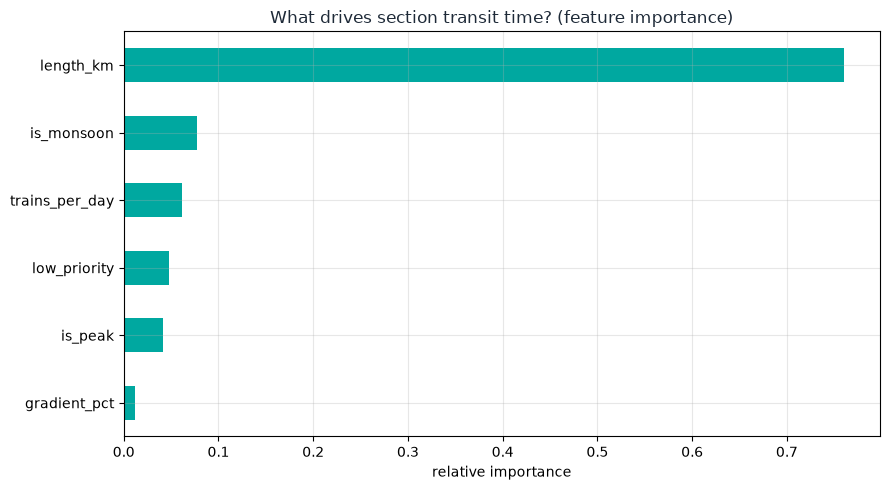

In [4]:
FEATURES = ["length_km", "trains_per_day", "gradient_pct", "is_monsoon", "is_peak", "low_priority"]
X, y = hist[FEATURES], hist["transit_hours"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

model = RandomForestRegressor(n_estimators=300, max_depth=9, random_state=0)
model.fit(Xtr, ytr)
pred = model.predict(Xte)
print(f"Transit-time model — R² on unseen data: {r2_score(yte, pred):.2f}")
print(f"Typical error (MAE)               : {mean_absolute_error(yte, pred):.2f} hours")

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
imp.plot.barh(color=THEME["teal"], ax=ax)
ax.set_title("What drives section transit time? (feature importance)")
ax.set_xlabel("relative importance"); plt.tight_layout(); plt.show()

**👁 What to look for**
- **Length** and **congestion (trains/day)** usually top the chart — long, busy sections dominate
  transit time. **Monsoon** and **gradient** add real, learnable effects.
- The model is accurate *and* explainable — an officer can defend *why* it predicted a number. That
  is what makes it usable in an audit / RTI context.

#### 🤔 Discussion
1. If **congestion** is a top driver, does that argue for more **capacity** on busy sections, or for
   **spreading traffic** across quieter ones? Routing (next) does the second — for free.
2. The model is only as good as the history behind it. What would a **monsoon washout year** do to
   its predictions, and how would you guard against over-trusting it?

---
# Part 4 — ROUTE: Turn Predictions into the Best Path (Engine 2)

Now the maps step. We pick **today's conditions** (say: monsoon on, peak hour, freight priority),
ask the model to **predict every section's time**, load those as **edge weights**, and find the
**fastest path** — plus the naïve **shortest-distance** path, to contrast.

In [5]:
# Today's scenario -> predict a time for every section
def predict_edge_times(monsoon, peak, low_priority):
    times = {}
    for a, b, d in G.edges(data=True):
        feat = pd.DataFrame([[d["length_km"], d["trains_per_day"], d["gradient_pct"],
                              monsoon, peak, low_priority]], columns=FEATURES)
        times[(a, b)] = float(model.predict(feat)[0])
    return times

edge_times = predict_edge_times(monsoon=1, peak=1, low_priority=1)
for (a, b), t in edge_times.items():
    G[a][b]["pred_time"] = t
    G[a][b]["nominal_time"] = G[a][b]["length_km"] / 45.0   # naive: distance at free speed

ORIG, DEST = "JNPT", "Pune"
fast_path = nx.shortest_path(G, ORIG, DEST, weight="pred_time")
short_path = nx.shortest_path(G, ORIG, DEST, weight="length_km")

def path_time(p):  return sum(G[p[i]][p[i+1]]["pred_time"] for i in range(len(p)-1))
def path_km(p):    return sum(G[p[i]][p[i+1]]["length_km"] for i in range(len(p)-1))

print("FASTEST route (uses predicted times):")
print("  ", " → ".join(fast_path))
print(f"   {path_time(fast_path):.1f} hrs over {path_km(fast_path):.0f} km")
print("\nSHORTEST-distance route (ignores congestion):")
print("  ", " → ".join(short_path))
print(f"   {path_time(short_path):.1f} hrs over {path_km(short_path):.0f} km")
print(f"\nTime saved by routing on predictions: {path_time(short_path)-path_time(fast_path):.1f} hrs")

FASTEST route (uses predicted times):
   JNPT → Panvel → Kalamboli → Karjat → Lonavala → Pune
   22.5 hrs over 507 km

SHORTEST-distance route (ignores congestion):
   JNPT → Kalyan → Karjat → Lonavala → Pune
   24.0 hrs over 482 km

Time saved by routing on predictions: 1.5 hrs


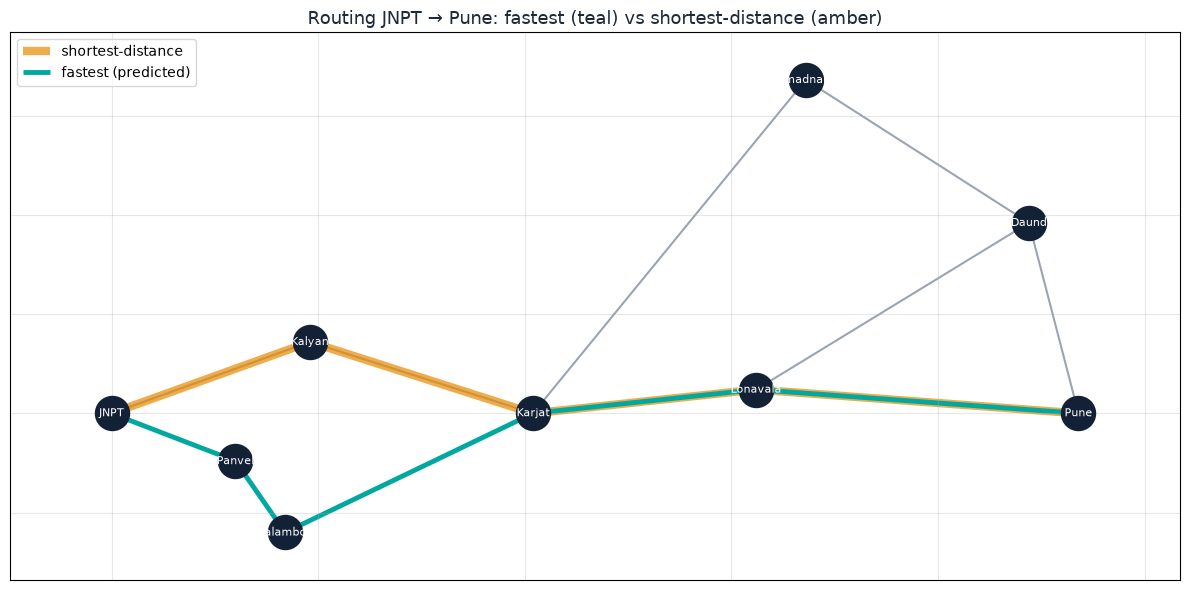

In [6]:
# Draw the two routes on the map
def edges_of(p): return set(frozenset([p[i], p[i+1]]) for i in range(len(p)-1))
fast_e, short_e = edges_of(fast_path), edges_of(short_path)

fig, ax = plt.subplots(figsize=(12, 6))
nx.draw_networkx_edges(G, pos, width=1.5, edge_color=THEME["grey"], ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=[tuple(e) for e in short_e], width=6,
                       edge_color=THEME["amber"], alpha=0.7, ax=ax, label="shortest-distance")
nx.draw_networkx_edges(G, pos, edgelist=[tuple(e) for e in fast_e], width=3.5,
                       edge_color=THEME["teal"], ax=ax, label="fastest (predicted)")
nx.draw_networkx_nodes(G, pos, node_size=600, node_color=THEME["navy"], ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", ax=ax)
ax.set_title(f"Routing {ORIG} → {DEST}: fastest (teal) vs shortest-distance (amber)", fontsize=13)
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

**👁 What to look for**
- The **fastest** path may be **longer in km** — it avoids the congested/steep sections the model
  flagged. This is the whole point of routing on *predicted time*, not distance.
- Swap the scenario (turn `monsoon=0`) and the best path can change. The map is **live**, not fixed.

#### 🤔 Discussion
1. A controller says "but that's the long way round." What one number convinces them it's right?
2. Who should be allowed to **override** the routing suggestion — and what should the system record
   when they do?

---
# Part 5 — DIGITAL TWIN: Decide Before You Act

The weighted graph is a **digital twin** — experiment safely. Two what-ifs officers face constantly:
- **Blockage:** a section goes down (accident / maintenance).
- **Degradation:** **condition monitoring** flags a section's asset health — we raise its predicted
  time so routing *automatically* steers around it. *(Your predictive-maintenance world feeding the
  movement decision.)*

In [7]:
TRACTION_COST_PER_HR = 18000   # ₹/hour of extra running (illustrative: fuel + crew + asset)

# --- What-if A: the Bhor Ghat washes out (as on 6 Jul 2026) ---
# Karjat–Lonavala is the ghat climb; block it and freight must take the inland Daund loop.
blocked = ("Karjat", "Lonavala") if G.has_edge("Karjat", "Lonavala") else None
if blocked is None:                       # fallback: busiest section on the fast path
    for i in range(len(fast_path)-1):
        a, b = fast_path[i], fast_path[i+1]
        if G[a][b]["trains_per_day"] >= 30:
            blocked = (a, b); break
    blocked = blocked or (fast_path[1], fast_path[2])

H = G.copy(); H.remove_edge(*blocked)
reroute = nx.shortest_path(H, ORIG, DEST, weight="pred_time")
base_t = path_time(fast_path)
new_t  = sum(H[reroute[i]][reroute[i+1]]["pred_time"] for i in range(len(reroute)-1))
print(f"WHAT-IF A — {blocked[0]} – {blocked[1]} (BHOR GHAT) WASHED OUT")
print("   New route:", " → ".join(reroute))
print(f"   Delay added: {new_t-base_t:5.1f} hrs  ≈ ₹{(new_t-base_t)*TRACTION_COST_PER_HR:,.0f} per rake")

# --- What-if B: condition monitoring flags a section as degraded (2x slower) ---
degraded = ("Karjat", "Lonavala")
G2 = G.copy()
G2[degraded[0]][degraded[1]]["pred_time"] *= 2.0     # health-adjusted travel time
new_path = nx.shortest_path(G2, ORIG, DEST, weight="pred_time")
print(f"\nWHAT-IF B — condition monitoring flags {degraded[0]}–{degraded[1]} as DEGRADED (2x slower)")
print("   Routing now prefers:", " → ".join(new_path))
print("   -> asset-health prediction automatically changed the movement decision.")

WHAT-IF A — Karjat – Lonavala (BHOR GHAT) WASHED OUT
   New route: JNPT → Panvel → Kalamboli → Karjat → Ahmadnagar → Daund → Pune
   Delay added:   4.9 hrs  ≈ ₹87,747 per rake

WHAT-IF B — condition monitoring flags Karjat–Lonavala as DEGRADED (2x slower)
   Routing now prefers: JNPT → Panvel → Kalamboli → Karjat → Ahmadnagar → Daund → Pune
   -> asset-health prediction automatically changed the movement decision.


**👁 What to look for**
- A **single blocked section** has a price — in hours and ₹, across *every* rake that used it. The
  twin lets you see the bill **before** committing.
- What-if B is the punchline of the whole MDP: **condition monitoring → digital twin → routing.**
  A health signal on an asset quietly re-routes freight, before anything fails.

#### 🤔 Discussion
1. If you could pre-compute re-routes for your **top 5 failure-prone sections**, how would that
   change how your control office handles a monsoon morning?
2. Where should the **human** step back into what-if B — should degraded-section re-routing be
   automatic, or advisory?

---
# Part 6 — ALLOCATE: A Scorecard, Not a Solver

Final decision: several **orders** (demand) and a few **available rakes**. We **predict the value**
of each rake-to-order match (revenue minus the empty-repositioning time the model predicts), build a
**scorecard**, and **assign greedily** — best match first. Then we compare against naïve
first-come-first-served.

> 🃏 *"Scorecard, not a solver" is the whole philosophy: no black-box optimiser you have to take on
> faith — just a transparent table where you can point at any number and ask "why?". Auditors love a
> table they can read. Solvers, less so.*


In [8]:
# Available rakes (each currently sitting at a node)
rakes = pd.DataFrame([
    {"rake": "R1", "at": "Pune"},     # far from the western demand
    {"rake": "R2", "at": "JNPT"},
    {"rake": "R3", "at": "Kalyan"},
    {"rake": "R4", "at": "Ahmadnagar"},
])
# Orders (demand): origin -> destination, tonnage, revenue per tonne
orders = pd.DataFrame([
    {"order": "O1", "src": "JNPT",  "dst": "Pune", "tonnes": 3600, "rate": 2.0},
    {"order": "O2", "src": "Kalamboli","dst": "Lonavala","tonnes": 3600, "rate": 2.0},
    {"order": "O3", "src": "Panvel",  "dst": "Pune", "tonnes": 3400, "rate": 2.1},
    {"order": "O4", "src": "Ahmadnagar","dst": "JNPT", "tonnes": 3200, "rate": 2.2},
])

def travel_hours(src, dst):
    return nx.shortest_path_length(G, src, dst, weight="pred_time")

# Score = haul revenue  -  cost of empty repositioning the rake to the order's origin
COST_PER_HR = 90000                                          # ₹/hour of empty running (illustrative)
score = {}
for r in rakes.itertuples():
    for o in orders.itertuples():
        revenue   = o.tonnes * o.rate * 1000                    # ₹ (rate in ₹/tonne-'000 illustr.)
        repo_hours = travel_hours(r.at, o.src)
        repo_cost = repo_hours * COST_PER_HR
        score[(r.rake, o.order)] = revenue - repo_cost
score_df = (pd.Series(score).unstack().round(0))
print("SCORECARD  (₹ value of each rake → order match; higher = better)")
print(score_df.to_string())

SCORECARD  (₹ value of each rake → order match; higher = better)
           O1         O2         O3         O4
R1  5173835.0  5581197.0  5362173.0  6236228.0
R2  7200000.0  6792638.0  6891662.0  5378873.0
R3  6738338.0  6330975.0  6429999.0  5705299.0
R4  5538873.0  5946235.0  5727211.0  7040000.0


In [9]:
# Greedy assignment: repeatedly take the best remaining (rake, order) pair
pairs = sorted(score.items(), key=lambda kv: kv[1], reverse=True)
used_r, used_o, assign = set(), set(), []
for (r, o), v in pairs:
    if r in used_r or o in used_o:
        continue
    assign.append((r, o, v)); used_r.add(r); used_o.add(o)

smart_value = sum(v for *_, v in assign)

# Naive baseline: first-come-first-served (orders in listed order -> first free rake in listed order)
free = list(rakes.rake); naive, naive_val = [], 0
for o in orders.order:
    r = free.pop(0)
    naive.append((r, o, score[(r, o)])); naive_val += score[(r, o)]

print("SCORECARD assignment (smart):")
for r, o, v in assign: print(f"   {r} → {o}   ₹{v:,.0f}")
print(f"   TOTAL value: ₹{smart_value:,.0f}")
print("\nFirst-come-first-served (naive):")
for r, o, v in naive: print(f"   {r} → {o}   ₹{v:,.0f}")
print(f"   TOTAL value: ₹{naive_val:,.0f}")
print(f"\nValue captured by the scorecard vs naive: ₹{smart_value-naive_val:,.0f} "
      f"(+{100*(smart_value-naive_val)/abs(naive_val):.0f}%)")

SCORECARD assignment (smart):
   R2 → O1   ₹7,200,000
   R4 → O4   ₹7,040,000
   R3 → O3   ₹6,429,999
   R1 → O2   ₹5,581,197
   TOTAL value: ₹26,251,196

First-come-first-served (naive):
   R1 → O1   ₹5,173,835
   R2 → O2   ₹6,792,638
   R3 → O3   ₹6,429,999
   R4 → O4   ₹7,040,000
   TOTAL value: ₹25,436,472

Value captured by the scorecard vs naive: ₹814,724 (+3%)


**👁 What to look for**
- The scorecard assigns **high-value orders to well-placed rakes**, avoiding costly empty
  repositioning — and it captures **more total value** than first-come-first-served.
- Every pick is **explainable**: you can point to the exact ₹ score. That's the difference between a
  decision you can defend in a review and a black-box you can't.

#### 🤔 Discussion
1. The scorecard here weighs **revenue and repositioning cost**. What *third* factor would you add
   for your division — SLA penalty, customer priority, emptying a congested yard?
2. When should an officer **overrule** the top-scored assignment? Name a case where the "lower-value"
   choice is the right one (fairness, strategic customer, safety).

---
# Part 7 — Wrap-Up: Prediction Powers the Decision

**What you built:** history → a transit-time model → routing on the map → a digital-twin what-if →
a scorecard allocation. Every decision rode on **one predictive engine**.

**The three things to remember**
1. **Decision = Prediction + a simple rule.** The intelligence is in Engine 1; keep Engine 2
   transparent so *you* stay in command.
2. **Routing is a maps problem** — predicted times on a network graph, shortest path. You already
   trust it on your phone.
3. **Allocation is a scorecard** — explainable, defensible, and good enough to beat the naïve baseline.

---
#### ✍️ Your turn (5 minutes)
- In Part 4, re-run with `monsoon=0, peak=0`. Does the fastest route change? What does that tell you
  about static, once-a-year routing rules?
- In Part 6, add an **SLA-penalty** term to the score (e.g., `- deadline_risk * penalty`) and see if
  the assignment changes. Which orders become more "valuable" once you price the risk of being late?

> **Across the session:** Hands-on 1 turned location data into a measured map; Hands-on 2 turned that
> map into routing and allocation decisions. That is decision intelligence for rail logistics —
> built on the same location-intelligence stack that already runs the world's roads.
